RNN - Erro dos pesos computados e usado somente durante a iteração

In [310]:
import numpy as np
from numpy import linalg as LA
import pandas as pd
import operator as op
import ipynbname
import math
import matplotlib.cm as cm
import optuna
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_pareto_front
from optuna.importance import get_param_importances
from optuna.exceptions import TrialPruned
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib as mpl
#from Testing.RTLO import *
from Functions.RLS import *
from Functions.Graphs import *
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import mean_absolute_percentage_error as MAPE
FileName = ipynbname.name()

params = [18, 10, 2, 0.1, 1e-08, 1e-05, 1e-06, 1]
df = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = df['PC1'].values

def prepare_data(sig, n, m):
    X, Y = [], []
    # O shift (s) é calculado para alinhar o final de Y com a predição futura
    # Seguindo sua lógica: se n=4, m=3 -> Y começa no índice 2 (hi_3)
    s = n - m + 1 
    
    for i in range(len(sig) - n - 1):
        X.append(sig[i : i + n])
        Y.append(sig[i + s : i + s + m])
        
    return np.array(X), np.array(Y)

def PlotPredError(rtlo,w=9,h=3):
    s = len(rtlo.yMAPE)
    t = rtlo.t
    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(w, h))
    axes = axes.flatten()
    ax1,ax2,ax3,ax4 = axes[0], axes[1], axes[2], axes[3]

    ax1.plot(t, rtlo.yR, color='black',label='Y-Real', linestyle='-')
    ax1.plot(t, rtlo.yP, color='blue',label='Y-Pred', linestyle='-')
    ax1.plot(t, rtlo.yL, color='blue', linestyle='--')
    ax1.plot(t, rtlo.yU, color='blue', linestyle='--')
    
    ax1.set_title('Y - Real x Prediction')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y', color='black')
    ax1.legend()

    ax2.plot(t, rtlo.eR, color='black',label='e-Real', linestyle='-')
    ax2.plot(t, rtlo.eP, color='blue',label='e-Pred', linestyle='-')
    ax2.set_title('Error - Real x Prediction')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Prediction Error', color='black') 
    ax2.legend()
    
    ax3.plot(t[-s:], rtlo.yRMSE, color='blue',label='RMSE', linestyle='-')
    ax3.set_title('RMSE')
    ax3.set_xlabel('X')
    ax3.set_ylabel('RMSE', color='black') 

    ax4.plot(t[-s:], rtlo.yMAPE, color='blue',label='MAPE', linestyle='-')
    ax4.set_title('MAPE')
    ax4.set_xlabel('X')
    ax4.set_ylabel('MAPE', color='black') 

    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()


In [691]:
def TANH(x):
    return np.tanh(x)
    #return 1 / (1 + np.exp(-x))
    #return np.maximum(0, x)

def dTANH(x):
    return 1/np.cosh(10*np.tanh(x/10))**2  # the tanh prevents oveflow
    #return f(x)*(1-f(x))
    #return np.where(x > 0, 1, 0)

def split_matrix(A):
    Ap = np.where(A > 0, A, 0)
    An = np.where(A < 0, A, 0)
    return An, Ap

def get_interval(A):
    v_max = np.max(A, axis=0)
    v_min = np.min(A, axis=0)
    
    return v_min, v_max

class RTLO:
    def __init__(self, nI,nR,nO,ηS=[0.1,0.1,0.1], τ=10,lr=1e-5):
        np.random.seed(42)
        self.k = 1
        self.t = np.array([])

        self.nI = nI
        self.nR = nR
        self.nO = nO

        self.ηS = np.array(ηS)
        self.τ = τ
        self.ρ = 0.01

        self.xSi = np.zeros(nI)
        self.xUi = np.zeros(nI)
        self.xLi = np.zeros(nI)

        self.hS = np.zeros(nR)
        self.hU = np.zeros(nR)
        self.hL = np.zeros(nR)

        self.htUF = np.zeros(nR)
        self.htUF = np.zeros(nR)
        self.uS = np.zeros(nR)
        self.decay = lr
        
        self.pS = np.zeros((self.nR, self.nR))
        self.qS = np.zeros((self.nR, self.nI))

        self.ΔOS = np.zeros((nO, nR))
        self.ΔRS = np.zeros((nR, nR))
        self.ΔIS = np.zeros((nR, nI))
        
        self.wI = self.xavier_uniform([nR, nI])
        self.wR = self.xavier_uniform([nR, nR])
        self.wO = self.xavier_uniform([nO, nR])
        self.BS = np.random.randn(nR, nO)/nO**0.5
        self.rls = RLS_LogarithmicRegressor(0.9,10000)
        
        self.yP = np.array([])
        self.yR = np.array([])
        self.yL = np.array([])
        self.yU = np.array([])

        self.eS = np.zeros(nI)
        self.eP = np.array([])
        self.eR = np.array([])

        self.μyRMSE = 0
        self.μyMAPE = 0
        self.μyWAPE = 0
        self.sWi = 0
        self.MPsum = 0

        self.yRMSE = np.array([])
        self.yMAPE = np.array([])
        self.yWAPE = np.array([])
        self.vMPsum = np.array([])

        self.rMAPE = np.array([])

        self.rulR = np.array([])
        self.rulP = np.array([])
        self.rulL = np.array([])
        self.rulU = np.array([])
    
    def xavier_uniform(self,shape):
        np.random.seed(42)
        n_in, n_out = shape
        limit = np.sqrt(6 / (n_in + n_out))
        return np.random.uniform(-limit, limit, size=shape) 


    def PredSingle(self,x):

        u = np.dot(self.wR, self.hS) + np.dot(self.wI, x)
        h = self.hS + (-self.hS + TANH(u))/self.τ
        y = np.dot(self.wO, h)

        return y

    def fit(self,xS,yR,store = False):

        k = self.k
        t = self.t
        τ = self.τ
        μyRMSEi = self.μyRMSE
        μyMAPEi = self.μyMAPE
        μyWAPEi = self.μyWAPE
        sWi = self.sWi

        nR = self.nR
        nI = self.nI
        nO = self.nO
        BS = self.BS
        wR = self.wR
        wI = self.wI
        wO = self.wO
        hSi = self.hS
        uSi = self.uS
        pS = self.pS
        qS = self.qS

        ΔRS = self.ΔRS
        ΔOS = self.ΔOS
        ΔIS = self.ΔIS
         
        η1,η2,η3 = self.ηS
        xSi = self.xSi

        uS = wR@hSi + wI@xS
        hS = hSi + (-hSi + TANH(uS))/τ
        yP = wO@hS
        eS = (yR-yP)
        
        μRMSE = (eS**2)[-1]
        μMAPE = np.abs((yR-yP)/yR)[-1]

        pS = np.outer(dTANH(uSi),hSi)/τ + (1-1/τ)*pS
        qS = np.outer(dTANH(uSi),xSi)/τ + (1-1/τ)*qS

        δOS = η1*np.outer(eS,hS)
        δRS = η2*np.outer((BS@eS),np.ones(nR))*pS
        δIS = η3*np.outer(np.dot(BS, eS),np.ones(nI))*qS

        self.ΔOS = ΔOS*(k-1)/k + δOS/k
        self.ΔRS = ΔRS*(k-1)/k + δRS/k
        self.ΔIS = ΔIS*(k-1)/k + δIS/k

        self.wI = self.wI + self.ΔIS
        self.wR = self.wR + self.ΔRS 
        self.wO = self.wO + self.ΔOS
        self.pS = pS
        self.qS = qS

        self.hS = hS
        self.hSI = hS
        
        self.xSi = xS

        rmse = (μyRMSEi*(k-1)/k + (μRMSE/k))**0.5
        mape = (μyMAPEi*(k-1)/k + (μMAPE/k))
        wape = (sWi*μyWAPEi + k*μMAPE)/(sWi+k)
        self.μyRMSE = rmse**2
        self.μyMAPE = mape
        self.μyWAPE = wape

        if store:
            self.yR = np.append(self.yR,yR[-1])
            self.yP = np.append(self.yP,yP[-1])
            self.yL = np.append(self.yL,yP[-1])
            self.yU = np.append(self.yU,yP[-1])
            self.yRMSE = np.append(self.yRMSE,rmse)
            self.yMAPE = np.append(self.yMAPE,mape)
            self.yWAPE = np.append(self.yWAPE,wape)
            self.vMPsum = np.append(self.vMPsum,self.MPsum)

        self.t = np.append(self.t,k+nI)
        self.sWi = self.sWi+k
        self.k = self.k+1
        self.ηS = self.ηS/(1 + self.decay*self.k)

    def PredRul(self, x,lim=0.2,rulR=None):
        xP = x.copy()
        rulP=0
        predict = True
        #print(self.ht)
        wR = self.wR
        wI = self.wI
        wO = self.wO
        hS = self.hS
        while predict:
            u = (wR @ hS) + (wI @ xP)
            hS = hS + (1/self.τ) * (-hS + TANH(u))
            yP = (wO @ hS)[-1]
            #print(yP)
            xP = np.delete(np.append(xP,yP),0)

            if predict:
                rulP = rulP+1

            if yP < lim:
                predict = False

            if rulP >= 110:
                rulP = 0
                break

        #if rulR is not None and self.k >=30:
        self.rulR = np.append(self.rulR,rulR)
        self.rulP = np.append(self.rulP,rulP)
        self.rMAPE = np.append(self.rMAPE,MAPE(self.rulR,self.rulP))

    def PredRulIntr(self, x,lim=0.2):
        xL,xU = (x-(self.ρ*self.eS)).copy(),(x+(self.ρ*self.eS)).copy()
        xP = x.copy()
        #print(xL[-5:])
        #print(x[-5:])
        #print(xU[-5:])
        rulL,rulU,rulP=0,0,0
        predict = True
        predP = True
        predL = True
        predU = True
        #print(self.ht)
        wR = self.wR
        wI = self.wI
        wO = self.wO
        wRp, wRn = np.maximum(0, self.wR), np.minimum(0, self.wR)
        wIp, wIn = np.maximum(0, self.wI), np.minimum(0, self.wI)
        wOp, wOn = np.maximum(0, self.wO), np.minimum(0, self.wO)
        #hU,hL = np.maximum(0, self.hS), np.minimum(0, self.hS)
        hP = self.hS
        hL,hU = self.hS.copy(), self.hS.copy()
        while predict:
            #print('hL:',hL[-5:])
            #print('hU:',hU[-5:])

            #print('xL:',xL[-3:],'xU:',xU[-3:])
            #print('xL:',xL[-3:],'xU:',xU[-3:])
            uP = wR@hP + wI@xP
            uL = (wRp @ hL + wRn @ hU) + (wIp @ xL + wIn @ xU)
            uU = (wRp @ hU + wRn @ hL) + (wIp @ xU + wIn @ xL)

            hP = hP + (-hP + TANH(uP))/self.τ
            hL = hL + ((1/self.τ) * (-hL + TANH(uL)))
            hU = hU + ((1/self.τ) * (-hU + TANH(uU)))
            
            yP = (wO@hP)[-1]
            yL = (wOp @ hL + wOn @ hU)[-1]
            yU = (wOp @ hU + wOn @ hL)[-1]
            #print('xL',xL[-2:],'xU',xU[-2:])

            xP = np.delete(np.append(xP,yP),0)
            xL = np.delete(np.append(xL,yL),0)
            xU = np.delete(np.append(xU,yU),0)
            

            #print('yL',yL,'xL',xL[-3:])
            #print('yU',yU,'xU',xU[-3:])
            if predL: 
                rulU = rulU+1
            if predU: 
                rulL = rulL+1
            if predP: 
                rulP = rulP+1
                
            if yL < lim:
                predL = False
            if yP < lim:
                predP = False
            if yU < lim:
                predU = False
            
            if not predL and not predP and not predU:
                break
            if rulP >=110 or rulL>=110 or rulU>=110:
                break
        self.rulL = np.append(self.rulL,rulL)
        self.rulP = np.append(self.rulP,rulP)
        self.rulU = np.append(self.rulU,rulU)
    
    def UpdateRLS(self,y_p,y_r):
        eP = np.abs(self.rls.predict(np.abs(y_p[-1])))
        eR = np.abs(y_p-y_r)[-1]
        self.rls.update(np.abs(y_p[-1]), eR)
        self.eR = np.append(self.eR,eR)
        self.eP = np.append(self.eP,eP)
        self.eS = np.append(self.eS,eP)
        self.eS = np.delete(self.eS,0)
        return eP
    
    


In [104]:
df = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = df['PC1'].values

def objective(trial):

    nI = trial.suggest_int('nI', 2, 20) 
    nR = trial.suggest_int('nR', 1, 20) 
    nO = trial.suggest_int('nO', 1, 20) 
    N1 = trial.suggest_categorical('N1', [1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1]) 
    N2 = trial.suggest_categorical('N2', [1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1]) 
    N3 = trial.suggest_categorical('N3', [1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1]) 
    lr = trial.suggest_categorical('lr', [1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1]) 
    τ = trial.suggest_int('τ', 1, 30)
    ηS = [N1,N2,N3]
    if nO > nI:
        raise TrialPruned()
    X,Y = prepare_data(sig,n=nI,m=nO)

    rtlo = RTLO(nI,nR,nO,ηS,τ,lr)
    for i,_ in enumerate(X):
        x,yR = X[i],Y[i]
        yP = rtlo.PredSingle(x)
        eP = rtlo.UpdateRLS(yP,yR)
        rtlo.fit(x,yR,store=False)

        mape = rtlo.μyWAPE      
        if i==55:
            trial.report(mape, step=i)
            if trial.should_prune(): raise optuna.TrialPruned()
        
    score = rtlo.μyWAPE

    return score

pruner=optuna.pruners.ThresholdPruner(upper=0.1, lower=0)
#pruner=optuna.pruners.ThresholdPruner(upper=3500, lower=0)
#sampler = optuna.samplers.TPESampler(multivariate=True,group=True,n_startup_trials=2500)
study = optuna.create_study(
    direction="minimize",
    #sampler=sampler,
    pruner=pruner,
    #storage="sqlite:///" + f'Optuna/{FileName}_Prdct.db', study_name=f'P{1}',
    load_if_exists=True)
study.optimize(objective, n_trials=1000)
best_params = study.best_params
params = list(best_params.values())
print('Erro:', study.best_value, 'parameters: ', params)

[I 2026-04-06 13:14:14,829] A new study created in memory with name: no-name-ae618757-3fb4-4247-9b9a-0d2525740f79
[I 2026-04-06 13:14:14,830] Trial 0 pruned. 
[I 2026-04-06 13:14:14,836] Trial 1 pruned. 
[I 2026-04-06 13:14:14,844] Trial 2 pruned. 
[I 2026-04-06 13:14:14,845] Trial 3 pruned. 
[I 2026-04-06 13:14:14,846] Trial 4 pruned. 
[I 2026-04-06 13:14:14,847] Trial 5 pruned. 
[I 2026-04-06 13:14:14,853] Trial 6 pruned. 
[I 2026-04-06 13:14:14,854] Trial 7 pruned. 
[I 2026-04-06 13:14:14,855] Trial 8 pruned. 
[I 2026-04-06 13:14:14,856] Trial 9 pruned. 
[I 2026-04-06 13:14:14,867] Trial 10 pruned. 
[I 2026-04-06 13:14:14,874] Trial 11 pruned. 
[I 2026-04-06 13:14:14,886] Trial 12 pruned. 
[I 2026-04-06 13:14:14,896] Trial 13 pruned. 
[I 2026-04-06 13:14:14,906] Trial 14 pruned. 
[I 2026-04-06 13:14:14,916] Trial 15 pruned. 
[I 2026-04-06 13:14:14,926] Trial 16 pruned. 
[I 2026-04-06 13:14:14,931] Trial 17 pruned. 
[I 2026-04-06 13:14:14,942] Trial 18 pruned. 
[I 2026-04-06 13:14:14

Erro: 0.15092063286841237 parameters:  [18, 20, 6, 0.1, 0.1, 0.0001, 1e-06, 2]


0.15092063286841237
0


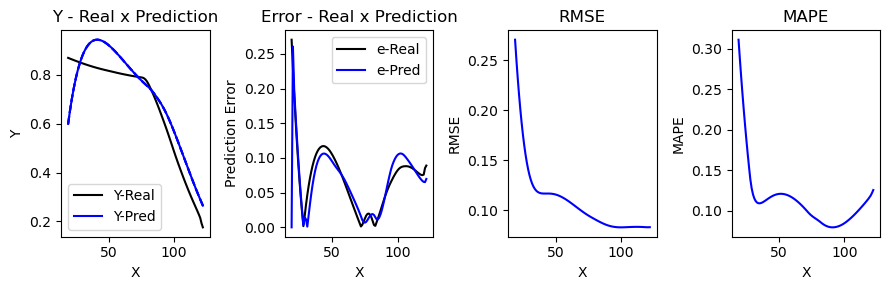

In [155]:
nI,nR,nO,N1,N2,N3,lr,τ= params
ηS = [N1,N2,N3]
X,Y = prepare_data(sig,n=nI,m=nO)
rtlo = RTLO(nI,nR,nO,ηS,τ,lr)
erroR = np.array([])
erroP = np.array([])
for i in range(len(X[:])):
    y_r = Y[i]
    y_p = rtlo.PredSingle(X[i])
    eP = rtlo.UpdateRLS(y_p,y_r[-1:])
    rulR = (len(sig)-nI-i-1)
    rtlo.PredRul(x=X[i],rulR=rulR)
    rtlo.fit(X[i],Y[i],store=True)
print(rtlo.μyWAPE)  
print(rtlo.MPsum)  
PlotPredError(rtlo)

In [705]:
df = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = df['PC1'].values

def objective(trial):

    nI = trial.suggest_int('nI', 2, 20) 
    nR = trial.suggest_int('nR', 1, 20) 
    nO = trial.suggest_int('nO', 1, 20) 
    N1 = trial.suggest_categorical('N1', [1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2]) 
    N2 = trial.suggest_categorical('N2', [1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2]) 
    N3 = trial.suggest_categorical('N3', [1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2]) 
    lr = trial.suggest_categorical('lr', [1e-8,1e-7,1e-6,1e-5,1e-4,1e-3]) 
    τ = trial.suggest_int('τ', 1, 25)
    ηS = [N1,N2,N3]
    if nO > nI:
        raise TrialPruned()
    X,Y = prepare_data(sig,n=nI,m=nO)

    rtlo = RTLO(nI,nR,nO,ηS,τ,lr)
    for i,_ in enumerate(X):
        x,yR = X[i],Y[i]
        yP = rtlo.PredSingle(x)
        eP = rtlo.UpdateRLS(yP,yR)
        rulR = (len(sig)-nI-i-1)
        rtlo.PredRul(x=X[i],rulR=rulR)
        rtlo.fit(x,yR,store=False)

        if i==50:
            if np.sum(rtlo.rulP[:i])<=20:
                raise TrialPruned()
        
    score = rtlo.rMAPE[-1] + rtlo.μyMAPE

    return score

#pruner=optuna.pruners.ThresholdPruner(upper=0.1, lower=0)
#pruner=optuna.pruners.ThresholdPruner(upper=0.5, lower=0)
sampler = optuna.samplers.TPESampler(multivariate=True,group=True,n_startup_trials=1000)
study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
    #pruner=pruner,
    #storage="sqlite:///" + f'Optuna/{FileName}_Prdct.db', study_name=f'P{1}',
    load_if_exists=True)
study.optimize(objective, n_trials=5000)
best_params = study.best_params
params = list(best_params.values())
print('Erro:', study.best_value, 'parameters: ', params)

c:\Users\claud\anaconda3\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

c:\Users\claud\anaconda3\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning:

Argument ``group`` is an experimental feature. The interface can change in the future.

[I 2026-04-06 16:30:07,442] A new study created in memory with name: no-name-7e1ec7b7-8f3b-4a52-b26b-0f85f7e47d06
[I 2026-04-06 16:30:07,443] Trial 0 pruned. 
[I 2026-04-06 16:30:07,445] Trial 1 pruned. 
[I 2026-04-06 16:30:07,539] Trial 2 finished with value: 2.143085833586886 and parameters: {'nI': 11, 'nR': 20, 'nO': 9, 'N1': 0.01, 'N2': 1e-06, 'N3': 0.001, 'lr': 1e-05, 'τ': 1}. Best is trial 2 with value: 2.143085833586886.
[I 2026-04-06 16:30:07,539] Trial 3 pruned. 
[I 2026-04-06 16:30:07,570] Trial 4 finished with value: 2.0840193594700396 and parameters: {'nI': 7, 'nR': 3, 'nO': 5, 'N1': 0.0001, 'N2': 1e-06, 'N3': 1

Erro: 0.32187850670398843 parameters:  [14, 18, 4, 1e-08, 1e-05, 1e-06, 1e-05, 21]


Erro: 0.38424737700792944 parameters:  [16, 10, 6, 0.0001, 0.001, 1e-08, 1e-07, 11]\
Erro: 0.32187850670398843 parameters:  [14, 18, 4, 1e-08, 1e-05, 1e-06, 1e-05, 21]\
Erro: 0.26666923626695643 parameters:  [10, 24, 5, 0.0001, 0.001, 1e-05, 0.001, 14]\
Erro: 0.25535467364862985 parameters:  [17, 18, 3, 1e-08, 1e-08, 1e-05, 1e-08, 10]



In [715]:
plot_parallel_coordinate(study)

0.11958594125196917
0.14826447005730414


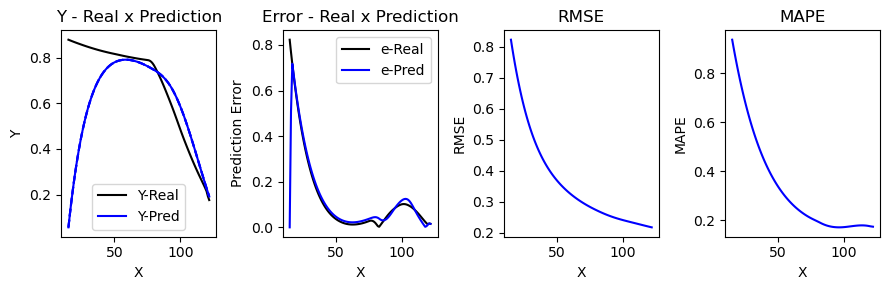

In [714]:
nI,nR,nO,N1,N2,N3,lr,τ= params
ηS = [N1,N2,N3]
X,Y = prepare_data(sig,n=nI,m=nO)
rtlo = RTLO(nI,nR,nO,ηS,τ,lr)
erroR = np.array([])
erroP = np.array([])
for i in range(len(X[:])):
    y_r = Y[i]
    y_p = rtlo.PredSingle(X[i])
    eP = rtlo.UpdateRLS(y_p,y_r[-1:])
    rulR = (len(sig)-nI-i-1)
    rtlo.PredRul(x=X[i],rulR=rulR)
    #rtlo.PredRulIntr(x=X[i])
    rtlo.fit(X[i],Y[i],store=True)
print(rtlo.μyWAPE)  
print(rtlo.rMAPE[-1])  
PlotPredError(rtlo)


In [711]:
nI,nR,nO,N1,N2,N3,lr,τ= params
ηS = [N1,N2,N3]
X,Y = prepare_data(sig,n=nI,m=nO)
rtlo = RTLO(nI,nR,nO,ηS,τ,lr)
erroR = np.array([])
erroP = np.array([])
for i in range(len(X[:])):
    y_r = Y[i]
    y_p = rtlo.PredSingle(X[i])
    eP = rtlo.UpdateRLS(y_p,y_r[-1:])
    rulR = (len(sig)-nI-i-1)
    #rtlo.PredRul(x=X[i],rulR=rulR)
    rtlo.PredRulIntr(x=X[i])
    rtlo.fit(X[i],Y[i],store=True)
#print(rtlo.μyWAPE)  
#print(rtlo.rMAPE[-1])  
#PlotPredError(rtlo)


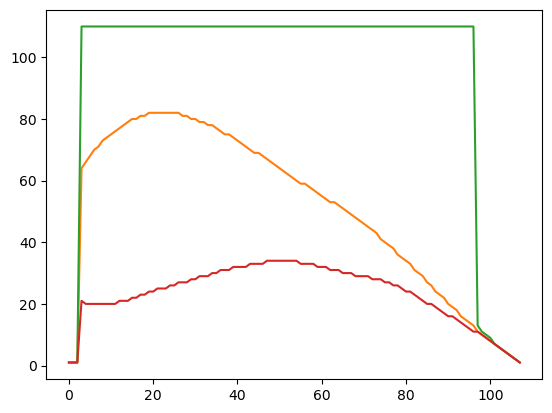

In [712]:

#plt.plot(rtlo.rulR)

plt.plot(rtlo.rulR)
plt.plot(rtlo.rulP)
plt.plot(rtlo.rulL)
plt.plot(rtlo.rulU)


In [676]:
nI,nR,nO,N1,N2,N3,lr,τ= params
ηS = [N1,N2,N3]
X,Y = prepare_data(sig,n=nI,m=nO)
xR,yR,yP = np.array([]),np.array([]),np.array([])

rtlo = RTLO(nI,nR,nO,ηS,τ,lr)
yL,yU = np.array([]),np.array([])
xR = np.array([])
erroR = np.array([])
erroP = np.array([])
i=0

In [680]:
print(i)
y_r = Y[i]
y_p = rtlo.PredSingle(X[i])
eP = rtlo.UpdateRLS(y_p,y_r)
rtlo.PredRulIntr(x=X[i])
rulR = (len(sig)-nI-i-1)

#rtlo.PredRul(x=X[i],rulR=)

rtlo.fit(X[i],Y[i],store=True)
i=i+1

3
yL: 0.4050950216906922 yP: 0.4169579580143377 yU: 0.4287068953021323
yL: 0.46799735527341074 yP: 0.4940976142304536 yU: 0.5199308293617022
yL: 0.49503206017839285 yP: 0.5402061893314225 yU: 0.5848389926613808
yL: 0.5193146265174272 yP: 0.5924162803514834 yU: 0.6642088398150039
yL: 0.5474160522861702 yP: 0.6590285284590409 yU: 0.7675199633832177
yL: 0.5585492694054246 yP: 0.7274204961821892 yU: 0.888870584596309
yL: 0.5485032932848879 yP: 0.8025811263127643 yU: 1.0396886017470814
yL: 0.4923586692796346 yP: 0.8753119706905322 yU: 1.218817826887927
yL: 0.3456081859646092 yP: 0.9224048044087713 yU: 1.418056527067695
yL: 0.12137885757967548 yP: 0.9668769759915069 yU: 1.6541297945392843
yL: -0.19910535202794155 yP: 0.9850991152034776 yU: 1.9086534703526545
yL: -0.5818173731155272 yP: 0.9923402974986021 yU: 2.1786246990330724
yL: -0.9834422639071718 yP: 1.0088253376996081 yU: 2.446120471143673
yL: -1.3715736582264386 yP: 1.0079704086868402 yU: 2.6952790312608848
yL: -1.7288040081430878 yP: 